# Численные схемы для уравнения Блэка–Шоулза

**Постановка задачи**  
Рассматриваем одномерное уравнение Блэка–Шоулза для европейского колл‑опциона:

$$
\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - rV = 0
$$

С параметрами $\sigma, r$, горизонтом $T$ и условием выплат в момент $t=T$: $V(S,T)=\max(S-K,0)$. Введём обратное время $\tau=T-t$ и перепишем PDE как

$$ V_{\tau}=\mathcal{L}V,\quad \mathcal{L}V=\frac12\sigma^2 S^2 V_{SS}+rS V_S - rV. $$

Сетка: $S_i=i\Delta S$, $i=0,\dots,M$, $\tau^n=n\Delta\tau$, $n=0,\dots,N$.

---

## Глава 1. Явная схема FTCS (Forward Time, Central Space)
**Схема:**
$$
V_i^{n+1} = V_i^n + \Delta\tau\left(\frac{1}{2}\sigma^2 S_i^2\frac{V_{i+1}^n-2V_i^n+V_{i-1}^n}{\Delta S^2} + rS_i\frac{V_{i+1}^n-V_{i-1}^n}{2\Delta S} - rV_i^n\right)
$$
**Граничные условия:** $V_0^{n}=0$, $V_M^{n}=S_{\max}-K e^{-r\tau^n}$

**Порядок и свойства:** 1-й порядок по времени ($O(\Delta\tau)$), 2-й порядок по пространству ($O(\Delta S^2)$). Условно устойчива (CFL: $\Delta\tau \lesssim \Delta S^2/(\sigma^2 S_{\max}^2)$).

---

## Глава 2. Неявная схема (Backward Euler) и метод прогонки
**Схема:**
$$
\frac{V_i^{n+1}-V_i^n}{\Delta\tau} = \mathcal{L}V^{n+1}_i
$$
Трёхдиагональная система для $V^{n+1}$:
$$
a_i V_{i-1}^{n+1} + b_i V_i^{n+1} + c_i V_{i+1}^{n+1} = d_i,\quad i=1,\dots,M-1
$$
Коэффициенты: $\alpha_i=\frac12\sigma^2 S_i^2$, $\beta_i=rS_i$
$$
a_i=-\frac{\Delta\tau\alpha_i}{\Delta S^2}+\frac{\Delta\tau\beta_i}{2\Delta S},\quad
b_i=1+\frac{2\Delta\tau\alpha_i}{\Delta S^2}+\Delta\tau r,\quad
c_i=-\frac{\Delta\tau\alpha_i}{\Delta S^2}-\frac{\Delta\tau\beta_i}{2\Delta S},\quad d_i=V_i^n+\text{(границы)}
$$

**Метод прогонки (Thomas algorithm):**
Прямой ход: $c'_1=c_1/b_1$, $d'_1=d_1/b_1$, далее $c'_i=c_i/(b_i-a_i c'_{i-1})$, $d'_i=(d_i-a_i d'_{i-1})/(b_i-a_i c'_{i-1})$; обратный ход: $x_{M-1}=d'_{M-1}$, $x_i=d'_i-c'_i x_{i+1}$.

**Порядок и свойства:** 1-й порядок по времени ($O(\Delta\tau)$), 2-й по пространству ($O(\Delta S^2)$). A‑stable, не условно устойчива, численно диссипативна.

---

## Глава 3. Схема Кранка–Николсона (Crank–Nicolson)
**Схема:**
$$
\frac{V_i^{n+1}-V_i^n}{\Delta\tau} = \frac12\left(\mathcal{L}V_i\^{n+1} + \mathcal{L}V_i^n\right)
$$
Трёхдиагональная система для $V^{n+1}$:
$$
\tilde a_i V_{i-1}^{n+1} + \tilde b_i V_i^{n+1} + \tilde c_i V_{i+1}^{n+1} = \tilde d_i
$$
Коэффициенты: $\alpha_i=\frac12\sigma^2 S_i^2$, $\beta_i=rS_i$
$$
\tilde a_i=-\frac12\Delta\tau\left(\frac{\alpha_i}{\Delta S^2}-\frac{\beta_i}{2\Delta S}\right),\quad
\tilde b_i=1+\frac12\Delta\tau\left(\frac{2\alpha_i}{\Delta S^2}+r\right),\quad
\tilde c_i=-\frac12\Delta\tau\left(\frac{\alpha_i}{\Delta S^2}+\frac{\beta_i}{2\Delta S}\right)
$$
Правая часть $\tilde d_i$ строится из $V^n$ с противоположными коэффициентами.

**Порядок и свойства:** 2-й порядок по времени ($O(\Delta\tau^2)$), 2-й по пространству ($O(\Delta S^2)$). Хорошая точность, трёхдиагональная система решается методом прогонки.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import log, sqrt, exp
from IPython.display import HTML
import matplotlib.animation as animation

# Параметры задачи (в задании)
sigma = 0.2
r = 0.05
T = 1.0        # год
K = 100.0
Smax_default = 3.0 * K

# plt.style.use('seaborn-darkgrid')

In [2]:
def bs_call_price(S, K, tau, sigma, r):
    """
    Black-Scholes formula for European call.
    tau = time to maturity (T - t)
    S can be scalar or numpy array.
    """
    S = np.array(S, dtype=float)
    tau = np.maximum(tau, 1e-16)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

print("BS(S=K) at t=0:", bs_call_price(K, K, T, sigma, r))

BS(S=K) at t=0: 10.450583572185565


In [3]:
def thomas(a, b, c, d): # Метод прогонки
    """
    Thomas algorithm for tridiagonal system.
    a, b, c: arrays of length n (a[0] unused or zero, c[-1] unused or zero)
    d: RHS of length n
    Returns x of length n solving:
      a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i], i=0..n-1
    (We assume a[0] == 0 and c[-1] == 0)
    """
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    x = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * cp[i-1]
        cp[i] = c[i] / denom if i < n-1 else 0.0  # last c ignored
        dp[i] = (d[i] - a[i] * dp[i-1]) / denom
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i+1]
    return x

In [4]:
def solve_ftcs(Smax, M, N_time, sigma, r, K, T): # Явная схема FTCS
    """
    FTCS explicit scheme.
    Smax: right boundary
    M: number of spatial intervals (so grid points M+1)
    N_time: number of time steps (tau direction, tau in [0, T])
    Returns S grid, tau grid, V array shape (N_time+1, M+1) where row 0 is tau=0 (payoff).
    """
    # grids
    dx = Smax / M
    dt = T / N_time
    S = np.linspace(0, Smax, M+1)
    tau = np.linspace(0, T, N_time+1)
    V = np.zeros((N_time+1, M+1))
    # initial payoff at tau=0
    V[0, :] = np.maximum(S - K, 0.0)
    # time-stepping forward in tau
    for n in range(0, N_time):
        V_next = np.zeros(M+1)
        V_next[0] = 0.0
        V_next[M] = Smax - K * np.exp(-r * tau[n+1])
        # update internal nodes i=1..M-1
        for i in range(1, M):
            Si = S[i]
            alpha = 0.5 * sigma**2 * Si**2
            beta = r * Si
            term2 = alpha * (V[n, i+1] - 2*V[n, i] + V[n, i-1]) / dx**2
            term1 = beta * (V[n, i+1] - V[n, i-1]) / (2*dx)
            V_next[i] = V[n, i] + dt * (term2 + term1 - r * V[n, i])
        V[n+1, :] = V_next
    return S, tau, V


In [5]:
def solve_backward_euler(Smax, M, N_time, sigma, r, K, T): # Неявная схема Backward Euler
    """
    Backward Euler (implicit) solver. Returns S, tau, V (shape (N_time+1, M+1))
    """
    dx = Smax / M
    dt = T / N_time
    S = np.linspace(0, Smax, M+1)
    tau = np.linspace(0, T, N_time+1)
    V = np.zeros((N_time+1, M+1))
    V[0, :] = np.maximum(S - K, 0.0)
    for n in range(0, N_time):
        a = np.zeros(M-1); b = np.zeros(M-1); c = np.zeros(M-1); d = np.zeros(M-1)
        for j in range(M-1):
            i = j + 1
            Si = S[i]
            alpha = 0.5 * sigma**2 * Si**2
            beta = r * Si
            a[j] = - (dt * alpha) / dx**2 + (dt * beta) / (2*dx)
            b[j] = 1.0 + (2*dt * alpha) / dx**2 + dt * r
            c[j] = - (dt * alpha) / dx**2 - (dt * beta) / (2*dx)
            d[j] = V[n, i] 
        V0_next = 0.0
        VM_next = Smax - K * np.exp(-r * tau[n+1])
        d[0] -= a[0] * V0_next
        d[-1] -= c[-1] * VM_next
        V_inner = thomas(a, b, c, d)
        V[n+1, 0] = V0_next
        V[n+1, 1:M] = V_inner
        V[n+1, M] = VM_next
    return S, tau, V

In [6]:
def solve_crank_nicolson(Smax, M, N_time, sigma, r, K, T): # Схема Кранка–Николсона
    """
    Crank-Nicolson solver. Returns S, tau, V (shape (N_time+1, M+1))
    """
    dx = Smax / M
    dt = T / N_time
    S = np.linspace(0, Smax, M+1)
    tau = np.linspace(0, T, N_time+1)
    V = np.zeros((N_time+1, M+1))
    V[0, :] = np.maximum(S - K, 0.0)
    for n in range(0, N_time):
        a = np.zeros(M-1); b = np.zeros(M-1); c = np.zeros(M-1); d = np.zeros(M-1)
        for j in range(M-1):
            i = j + 1
            Si = S[i]
            alpha = 0.5 * sigma**2 * Si**2
            beta = r * Si
            a[j] = -0.5 * dt * (alpha / dx**2 - beta / (2*dx))
            b[j] = 1.0 + 0.5 * dt * (2*alpha / dx**2 + r)
            c[j] = -0.5 * dt * (alpha / dx**2 + beta / (2*dx))
            # RHS coefficients (from previous time level)
            a_rhs = 0.5 * dt * (alpha / dx**2 - beta / (2*dx))
            b_rhs = 1.0 - 0.5 * dt * (2*alpha / dx**2 + r)
            c_rhs = 0.5 * dt * (alpha / dx**2 + beta / (2*dx))
            d[j] = a_rhs * V[n, i-1] + b_rhs * V[n, i] + c_rhs * V[n, i+1]
        # boundaries
        V0_next = 0.0
        VM_next = Smax - K * np.exp(-r * tau[n+1])
        # account for known boundary values in RHS
        d[0] -= a[0] * V0_next
        d[-1] -= c[-1] * VM_next
        V_inner = thomas(a, b, c, d)
        V[n+1, 0] = V0_next
        V[n+1, 1:M] = V_inner
        V[n+1, M] = VM_next
    return S, tau, V


/tmp/ipykernel_65555/2772851222.py:9: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
/tmp/ipykernel_65555/3871659893.py:27: RuntimeWarning: overflow encountered in scalar multiply
  term2 = alpha * (V[n, i+1] - 2*V[n, i] + V[n, i-1]) / dx**2
/tmp/ipykernel_65555/3871659893.py:29: RuntimeWarning: invalid value encountered in scalar add
  V_next[i] = V[n, i] + dt * (term2 + term1 - r * V[n, i])
/tmp/ipykernel_65555/3871659893.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  term1 = beta * (V[n, i+1] - V[n, i-1]) / (2*dx)


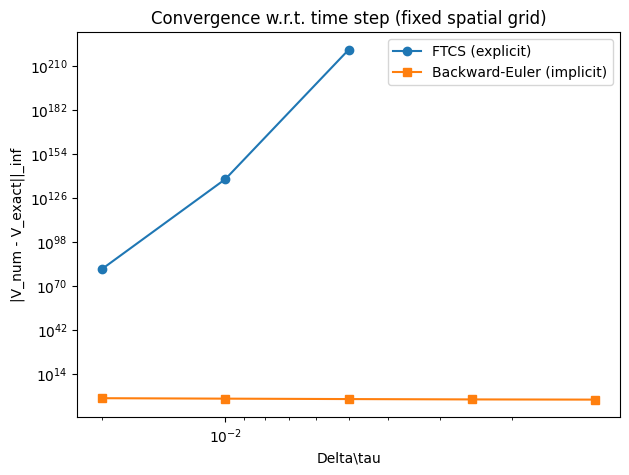

S[idx_K]=100.5000, index 67
At S=K (analytic): 10.771333330239663
FTCS: -6.283813717863708e+235
Backward-Euler: 10.769154816104919
Crank-Nicolson: 10.770477184273192
Sup-norm errors (FTCS, BE, CN): nan 0.002751175737343292 0.0018083900396724806


In [7]:
def sup_norm_error(V_num, V_exact):
    return np.max(np.abs(V_num - V_exact))

# параметры сетки
Smax = Smax_default
M = 200  
S, _, _ = solve_backward_euler(Smax, M, 10, sigma, r, K, T) 
# подберём разные dt (N_time)
N_list = np.array([50, 100, 200, 400, 800])
errors_ftcs = []
errors_be = []
dt_list = []

for N_time in N_list:
    dt = T / N_time
    dt_list.append(dt)
    # FTCS: нужно удостовериться в устойчивости; если dt слишком велик — схема взорвётся
    try:
        S, tau, V_ftcs = solve_ftcs(Smax, M, N_time, sigma, r, K, T)
    except Exception as e:
        print("FTCS failure at N_time=", N_time, e)
        V_ftcs = None
    S, tau, V_be = solve_backward_euler(Smax, M, N_time, sigma, r, K, T)
    # аналитическое решение на конечном слое (tau = T)
    V_exact = bs_call_price(S, K, T, sigma, r)  # price at tau=T (i.e. t=0)
    if V_ftcs is not None:
        errors_ftcs.append(sup_norm_error(V_ftcs[-1, :], V_exact))
    else:
        errors_ftcs.append(np.nan)
    errors_be.append(sup_norm_error(V_be[-1, :], V_exact))

plt.figure(figsize=(7,5))
plt.loglog(dt_list, errors_ftcs, 'o-', label='FTCS (explicit)')
plt.loglog(dt_list, errors_be, 's-', label='Backward-Euler (implicit)')
plt.gca().invert_xaxis()
plt.xlabel(r'Delta\tau')
plt.ylabel(r'|V_num - V_exact||_inf')
plt.title('Convergence w.r.t. time step (fixed spatial grid)')
plt.legend()
plt.show()

idx_K = np.argmin(np.abs(S - K))
print(f"S[idx_K]={S[idx_K]:.4f}, index {idx_K}")
N_show = N_list[-1]
S, tau, V_ftcs = solve_ftcs(Smax, M, N_show, sigma, r, K, T)
S, tau, V_be = solve_backward_euler(Smax, M, N_show, sigma, r, K, T)
S, tau, V_cn = solve_crank_nicolson(Smax, M, N_show, sigma, r, K, T)
V_exact = bs_call_price(S, K, T, sigma, r)

print("At S=K (analytic):", V_exact[idx_K])
print("FTCS:", V_ftcs[-1, idx_K])
print("Backward-Euler:", V_be[-1, idx_K])
print("Crank-Nicolson:", V_cn[-1, idx_K])
print("Sup-norm errors (FTCS, BE, CN):",
      sup_norm_error(V_ftcs[-1,:], V_exact),
      sup_norm_error(V_be[-1,:], V_exact),
      sup_norm_error(V_cn[-1,:], V_exact))


Видно, что для схемы FTCS произошел взрыв схемы, то есть схема стала неустойчивой. В начале я писал, что такое может произойти.

/tmp/ipykernel_65555/2772851222.py:9: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


Smax  |  sup-error  | S_at_K  | V_CN(S=K)  | V_exact(S=K)
  150.0  9.308259e-02   99.750   10.291656   10.291964
  200.0  2.497173e-03  100.000   10.448114   10.450584
  300.0  1.807724e-03  100.500   10.770478   10.771333


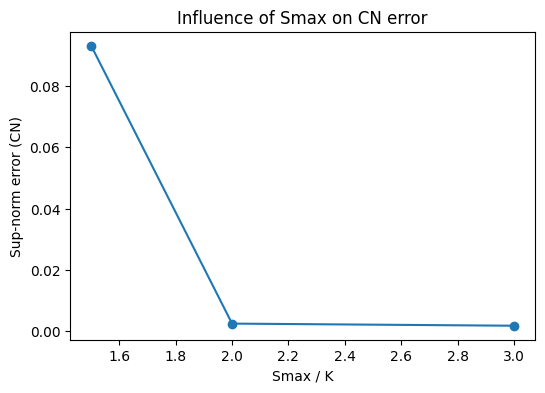

In [8]:
Smax_list = [1.5*K, 2.0*K, 3.0*K]
M = 200
N_time = 400  # достаточно мелкий по времени для CN (CN 2-й порядок)
errors_smax = []
vals_at_K = []

for Smax in Smax_list:
    S, tau, V_cn = solve_crank_nicolson(Smax, M, N_time, sigma, r, K, T)
    V_exact = bs_call_price(S, K, T, sigma, r)
    err = sup_norm_error(V_cn[-1, :], V_exact)
    errors_smax.append(err)
    idx_K = np.argmin(np.abs(S - K))
    vals_at_K.append((S[idx_K], V_cn[-1, idx_K], V_exact[idx_K]))

print("Smax  |  sup-error  | S_at_K  | V_CN(S=K)  | V_exact(S=K)")
for smax, err, info in zip(Smax_list, errors_smax, vals_at_K):
    print(f"{smax:7.1f}  {err:12.6e}  {info[0]:7.3f}  {info[1]:10.6f}  {info[2]:10.6f}")

plt.figure(figsize=(6,4))
plt.plot([s/K for s in Smax_list], errors_smax, 'o-')
plt.xlabel('Smax / K')
plt.ylabel('Sup-norm error (CN)')
plt.title('Influence of Smax on CN error')
plt.show()


In [9]:
# Для анимации используем ранее рассчитанный V_cn при Smax = 3K
Smax = 3*K
M = 300
N_time = 300
S, tau, V_cn = solve_crank_nicolson(Smax, M, N_time, sigma, r, K, T)

fig, ax = plt.subplots(figsize=(8,5))
line, = ax.plot(S, V_cn[0,:])
ax.set_xlim(0, Smax)
ax.set_ylim(0, Smax - K + 20)
ax.set_xlabel('S')
ax.set_ylabel('Option price V(S,t)')
ax.set_title('Crank–Nicolson solution evolution (tau increasing)')

def update(frame):
    line.set_ydata(V_cn[frame, :])
    ax.set_title(f'Crank–Nicolson: tau = {tau[frame]:.4f}')
    return (line,)

ani = animation.FuncAnimation(fig, update, frames=range(0, N_time+1, max(1, N_time//100)), blit=True)
plt.close(fig) 

HTML(ani.to_jshtml())
